# 📊 Notebook 01: Exploratory Data Analysis (EDA)

In this notebook, we will explore the **SMS Spam Collection Dataset** to understand its structure, analyze class distributions, examine text lengths, and visualize the most frequent words in ham and spam messages using word clouds.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# Set styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load and Preview Dataset

Let's load the data from `data/spam.csv` which was downloaded and formatted from the UCI repository.

In [2]:
csv_path = os.path.join("..", "data", "spam.csv")
df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nNull Value Count:")
print(df.isnull().sum())

Dataset Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Null Value Count:
label      0
message    0
dtype: int64


## 2. Class Distribution Analysis

Let's check the distribution of the target labels (`ham` vs `spam`). This helps us determine if there is a class imbalance.

Class Counts:
  Ham: 4825 (86.59%)
  Spam: 747 (13.41%)


C:\Users\tapas\AppData\Local\Temp\ipykernel_33916\4075871036.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#3182bd', '#e34a33'])


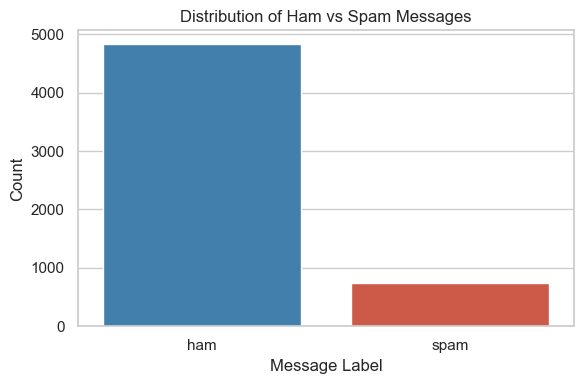

In [3]:
# Count and percentage of each label
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

print("Class Counts:")
for label, count in class_counts.items():
    print(f"  {label.capitalize()}: {count} ({class_pct[label]:.2f}%)")

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette=['#3182bd', '#e34a33'])
plt.title('Distribution of Ham vs Spam Messages')
plt.xlabel('Message Label')
plt.ylabel('Count')
plt.tight_layout()
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/class_distribution.png', dpi=300)
plt.show()

## 3. Message Length Distribution

We hypothesize that spam messages might tend to be longer than legitimate (ham) messages due to details, URLs, and call-to-actions.
Let's verify this by checking message length distributions.

Descriptive statistics for message length:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


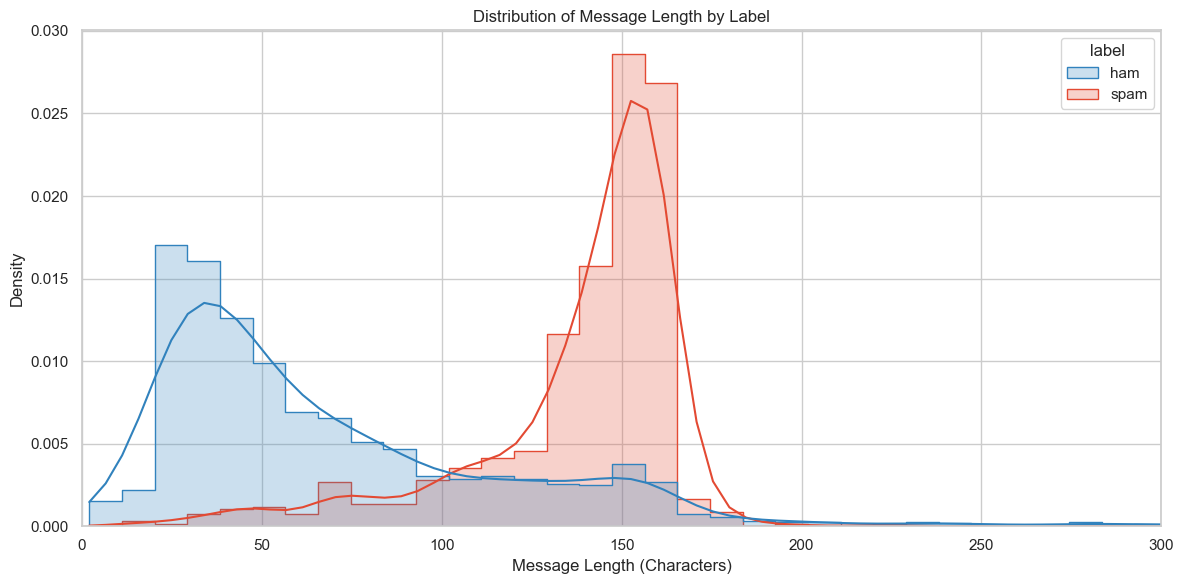

In [4]:
# Compute characters length of each message
df['message_length'] = df['message'].astype(str).apply(len)

# Descriptive stats by label
print("Descriptive statistics for message length:")
display(df.groupby('label')['message_length'].describe())

# Plot length distribution (histogram + KDE)
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='message_length', hue='label', bins=100, kde=True, 
             palette=['#3182bd', '#e34a33'], element='step', stat='density', common_norm=False)
plt.title('Distribution of Message Length by Label')
plt.xlabel('Message Length (Characters)')
plt.ylabel('Density')
plt.xlim(0, 300) # zoom in on most messages
plt.tight_layout()
plt.savefig('../plots/length_distribution.png', dpi=300)
plt.show()

## 4. Generate Word Clouds

Word Clouds visually represent the frequency of words in our text. Higher frequency words appear larger in the cloud.

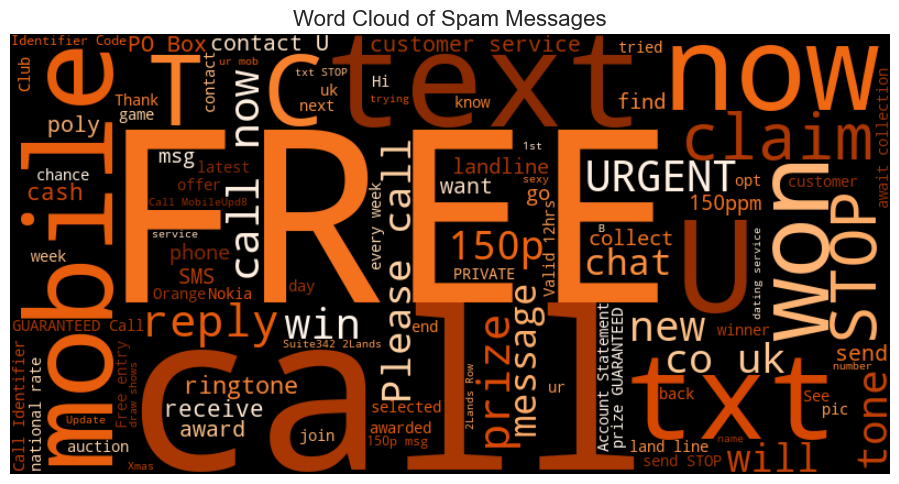

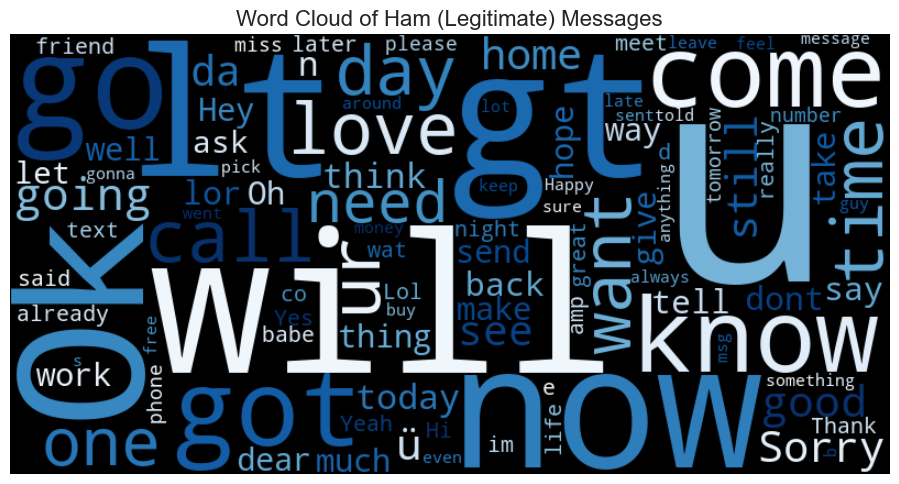

In [5]:
# Combine all messages for each class
spam_text = " ".join(df[df['label'] == 'spam']['message'].astype(str))
ham_text = " ".join(df[df['label'] == 'ham']['message'].astype(str))

# Generate Word Cloud for Spam
wordcloud_spam = WordCloud(width=800, height=400, background_color='black', 
                          colormap='Oranges', max_words=100).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Spam Messages', fontsize=16)
plt.tight_layout()
plt.savefig('../plots/wordcloud_spam.png', dpi=300)
plt.show()

# Generate Word Cloud for Ham
wordcloud_ham = WordCloud(width=800, height=400, background_color='black', 
                         colormap='Blues', max_words=100).generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Ham (Legitimate) Messages', fontsize=16)
plt.tight_layout()
plt.savefig('../plots/wordcloud_ham.png', dpi=300)
plt.show()

## 5. Top 20 Most Common Words in Spam

Let's extract the spam messages, clean them simple (remove stopwords, punctuation, digits), and find the top 20 most frequent words.

Top 20 most common words in Spam messages:


,Word,Count
0,call,370
1,free,228
2,txt,170
3,ur,144
4,mobile,129
5,stop,128
6,text,126
7,claim,113
8,reply,104
9,www,98


C:\Users\tapas\AppData\Local\Temp\ipykernel_33916\1899432641.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=top_20_spam, palette='Oranges_r')


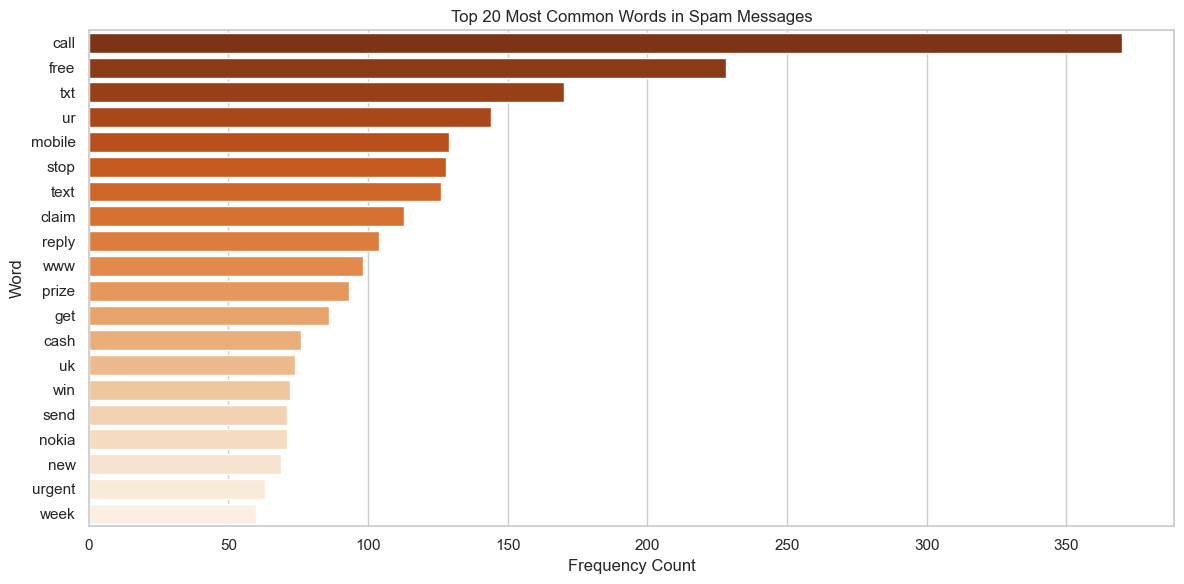

In [6]:
# Download stopwords if needed
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def simple_clean(text):
    # Lowercase, keep only letters
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    # Remove stopwords
    words = [w for w in words if w not in stop_words and len(w) > 1]
    return words

# Tokenize spam messages
all_spam_words = []
for msg in df[df['label'] == 'spam']['message'].astype(str):
    all_spam_words.extend(simple_clean(msg))

# Calculate frequencies
word_counts = Counter(all_spam_words)
top_20_spam = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Count'])

print("Top 20 most common words in Spam messages:")
display(top_20_spam)

# Plot top 20 words in spam
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Word', data=top_20_spam, palette='Oranges_r')
plt.title('Top 20 Most Common Words in Spam Messages')
plt.xlabel('Frequency Count')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig('../plots/top_20_spam_words.png', dpi=300)
plt.show()